# ⚡ EDA — Données foudre Meteorage
**Objectif :** Explorer les données historiques d'éclairs autour de 6 aéroports pour préparer un modèle de prédiction de fin d'alerte orage.

**Aéroports :** Ajaccio, Bastia, Bron, Nantes, Biarritz, Pise  
**Période :** 2016–2025 | **Rayon :** 30 km autour de chaque aéroport

## 0. Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

AIRPORTS = ['Ajaccio', 'Bastia', 'Bron', 'Nantes', 'Biarritz', 'Pise']
AIRPORT_COORDS = {
    'Bron':    (4.9389,  45.7294),
    'Bastia':  (9.4837,  42.5527),
    'Ajaccio': (8.8029,  41.9236),
    'Nantes':  (-1.6107, 47.1532),
    'Pise':    (10.399,  43.695),
    'Biarritz':(-1.524,  43.4683),
}
print('✅ Imports OK')

✅ Imports OK


## 1. Chargement des données

In [3]:
path = '../data/segment_alerts_all_airports_train.csv'
df = pd.read_csv(path)
print(f'Shape : {df.shape}')
df.head()

Shape : (507071, 13)


,lightning_id,lightning_airport_id,date,lon,lat,amplitude,maxis,icloud,dist,azimuth,airport,airport_alert_id,is_last_lightning_cloud_ground
0,1,1,2016-01-02 14:53:36+00:00,9.0559,42.0826,-9.90,0.3,False,27.360653,57.852343,Ajaccio,NaN,NaN
1,2,2,2016-01-02 14:53:36+00:00,9.0236,42.0953,-3.33,0.2,True,26.383167,52.117828,Ajaccio,NaN,NaN
2,3,3,2016-01-02 21:22:53+00:00,8.8585,42.0456,-18.68,0.4,True,14.313391,24.500543,Ajaccio,NaN,NaN
3,4,4,2016-01-02 21:22:53+00:00,8.8517,42.0517,-7.51,0.2,False,14.794117,20.854458,Ajaccio,1.0,False
4,5,5,2016-01-02 21:24:46+00:00,8.8728,42.0494,-6.01,0.2,False,15.124224,29.058471,Ajaccio,1.0,False


In [4]:
# 2.1 — Types & parsing
df['date'] = pd.to_datetime(df['date'], utc=True)
df['icloud'] = df['icloud'].astype(bool)
df['is_last_lightning_cloud_ground'] = df['is_last_lightning_cloud_ground'].astype('boolean')

# 2.2 — Variables temporelles
df['year']   = df['date'].dt.year
df['month']  = df['date'].dt.month
df['hour']   = df['date'].dt.hour
df['season'] = df['month'].map({
    12:'Hiver', 1:'Hiver', 2:'Hiver',
    3:'Printemps', 4:'Printemps', 5:'Printemps',
    6:'Été', 7:'Été', 8:'Été',
    9:'Automne', 10:'Automne', 11:'Automne'
})

# 2.3 — Alerte Pise 2016 (données intra-nuage potentiellement biaisées)
mask_pise_2016 = (df['airport'] == 'Pise') & (df['year'] == 2016) & (df['icloud'] == True)
print(f"⚠️  Éclairs intra-nuage Pise 2016 : {mask_pise_2016.sum()} (à exclure si analyse icloud)")
df_clean = df.copy()#[~mask_pise_2016]

# 2.4 — Sous-ensembles utiles
df_20km  = df_clean[df_clean['dist'] <= 20].copy()   # zone opérationnelle
df_cg    = df_clean[df_clean['icloud'] == False].copy()  # éclairs nuage-sol uniquement
df_cg_20 = df_cg[df_cg['dist'] <= 20].copy()

print(f"\nDataset nettoyé     : {df_clean.shape[0]:,} éclairs")
print(f"Éclairs ≤ 20 km     : {df_20km.shape[0]:,}")
print(f"Éclairs nuage-sol   : {df_cg.shape[0]:,}")
print(f"CG ≤ 20 km          : {df_cg_20.shape[0]:,}")

⚠️  Éclairs intra-nuage Pise 2016 : 19404 (à exclure si analyse icloud)

Dataset nettoyé     : 507,071 éclairs
Éclairs ≤ 20 km     : 220,498
Éclairs nuage-sol   : 128,992
CG ≤ 20 km          : 56,599


## 2. Nettoyage & Préparation

In [5]:
# 2.5 — Valeurs manquantes
print("=== Valeurs manquantes ===")
missing = df_clean.isnull().sum()
missing_pct = (missing / len(df_clean) * 100).round(2)
pd.DataFrame({'count': missing, 'pct': missing_pct})[missing > 0]

=== Valeurs manquantes ===


,count,pct
airport_alert_id,450472,88.84
is_last_lightning_cloud_ground,450472,88.84


In [6]:
# 2.6 — Statistiques descriptives
df_clean[['amplitude', 'maxis', 'dist', 'azimuth']].describe().round(2)

,amplitude,maxis,dist,azimuth
count,507071.00,507071.00,507071.00,507071.00
mean,-2.25,1.03,20.24,168.81
std,20.25,1.36,6.94,97.59
min,-429.50,0.02,0.04,0.00
25%,-5.61,0.11,15.41,85.24
50%,-1.56,0.24,21.44,156.72
75%,4.62,1.54,26.11,251.48
max,497.00,6.90,30.00,359.98


## Durée médiane d une alerte

In [7]:
# Durée médiane d'une alerte (en minutes)
alert_durations = (
    df
    .dropna(subset=['airport_alert_id'])
    .groupby(['airport', 'airport_alert_id'])['date']
    .agg(debut='min', fin='max')
    .assign(duree_min=lambda x: (x['fin'] - x['debut']).dt.total_seconds() / 60)
)

mediane_globale = alert_durations['duree_min'].median()
mediane_par_aeroport = alert_durations.groupby('airport')['duree_min'].median()

print(f"Durée médiane globale : {mediane_globale:.1f} minutes")
print("\nPar aéroport :")
print(mediane_par_aeroport.round(1).to_string())

Durée médiane globale : 8.9 minutes

Par aéroport :
airport
Ajaccio      8.4
Bastia      10.1
Biarritz     7.1
Nantes       8.8
Pise        11.3


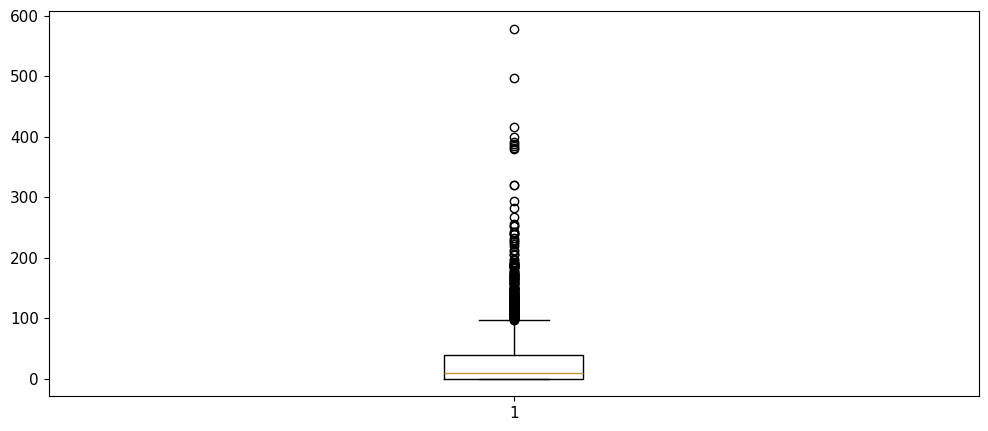

In [8]:
plt.boxplot(alert_durations.duree_min) 
plt.show()

In [33]:
alert_durations.describe()

,duree_min
count,2627.000000
mean,29.904130
std,50.280164
min,0.000000
25%,0.000000
50%,8.916667
75%,38.591667
max,578.716667


## 3. Vue d'ensemble : Volume par aéroport

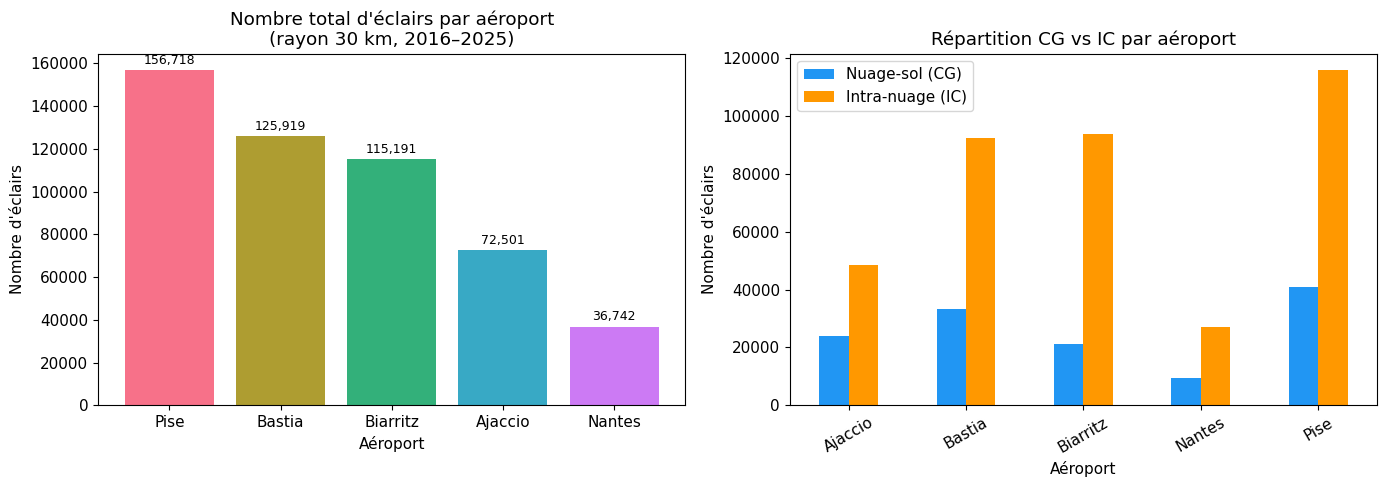

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3.1 Total éclairs par aéroport
counts = df_clean.groupby('airport').size().sort_values(ascending=False)
bars = axes[0].bar(counts.index, counts.values, color=sns.color_palette('husl', len(counts)))
axes[0].set_title('Nombre total d\'éclairs par aéroport\n(rayon 30 km, 2016–2025)')
axes[0].set_xlabel('Aéroport')
axes[0].set_ylabel('Nombre d\'éclairs')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# 3.2 Répartition nuage-sol vs intra-nuage
type_counts = df_clean.groupby(['airport', 'icloud']).size().unstack(fill_value=0)
type_counts.columns = ['Nuage-sol (CG)', 'Intra-nuage (IC)']
type_counts.plot(kind='bar', ax=axes[1], color=['#2196F3', '#FF9800'])
axes[1].set_title('Répartition CG vs IC par aéroport')
axes[1].set_xlabel('Aéroport')
axes[1].set_ylabel('Nombre d\'éclairs')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Saisonnalité & Temporalité

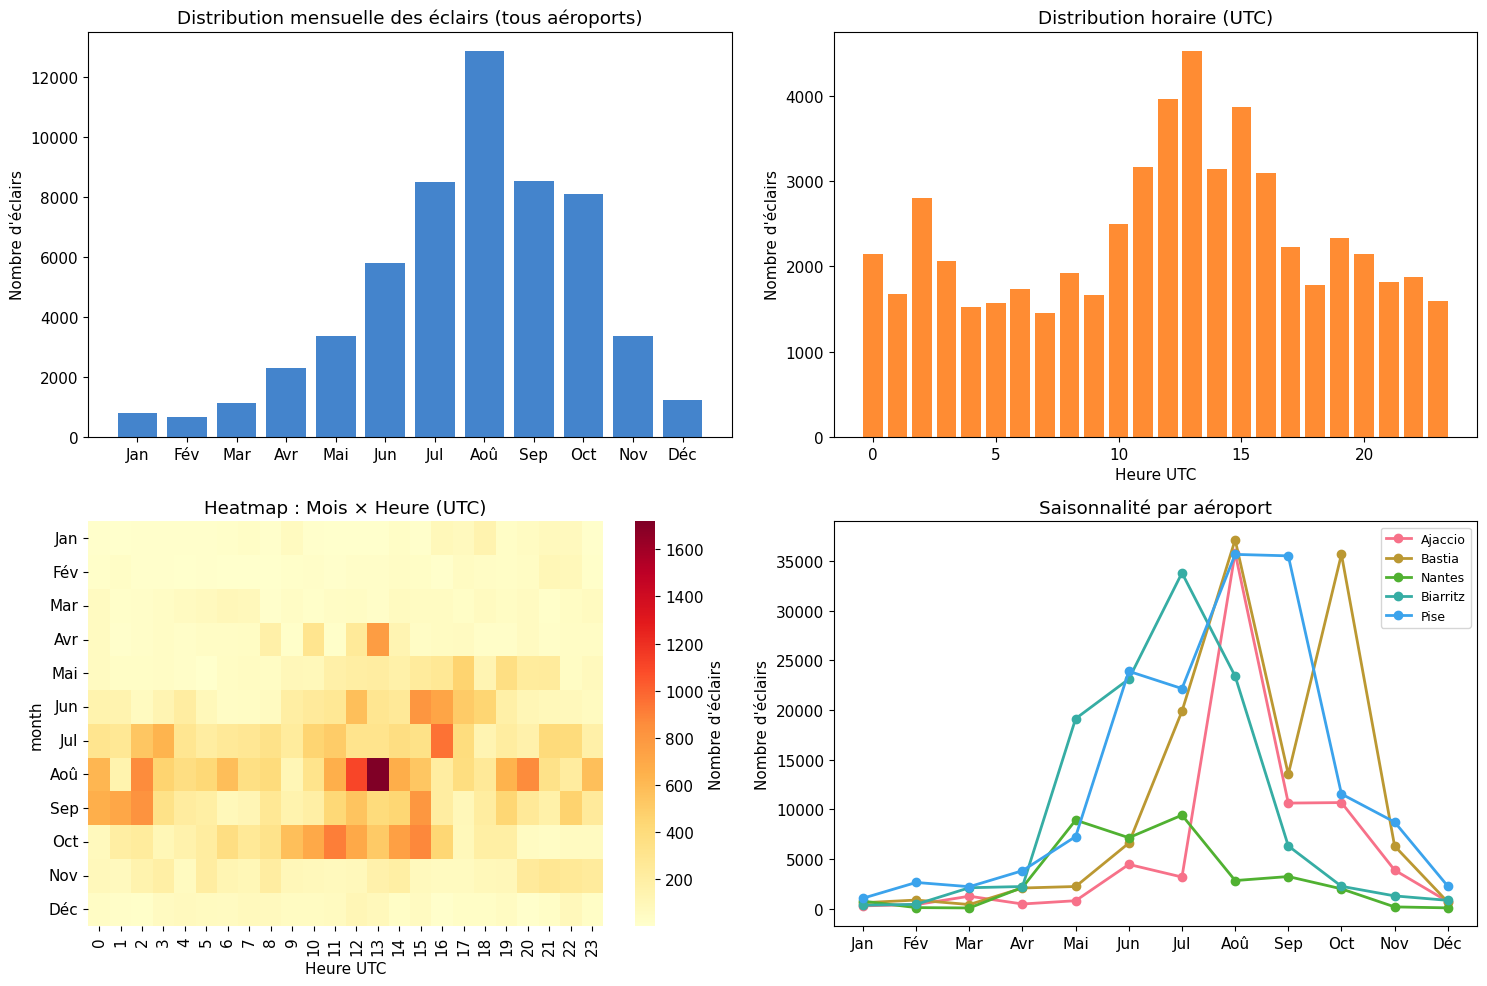

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
MONTH_LABELS = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

# 4.1 — Distribution mensuelle (tous aéroports)
monthly = df_cg_20.groupby('month').size()
axes[0,0].bar(range(1,13), [monthly.get(m,0) for m in range(1,13)],
              color='#1565C0', alpha=0.8)
axes[0,0].set_xticks(range(1,13))
axes[0,0].set_xticklabels(MONTH_LABELS)
axes[0,0].set_title('Distribution mensuelle des éclairs (tous aéroports)')
axes[0,0].set_ylabel('Nombre d\'éclairs')

# 4.2 — Distribution horaire
hourly = df_cg_20.groupby('hour').size()
axes[0,1].bar(range(24), [hourly.get(h,0) for h in range(24)],
              color='#FF6F00', alpha=0.8)
axes[0,1].set_title('Distribution horaire (UTC)')
axes[0,1].set_xlabel('Heure UTC')
axes[0,1].set_ylabel('Nombre d\'éclairs')

# 4.3 — Heatmap mois × heure
heatmap_data = df_cg_20.groupby(['month', 'hour']).size().unstack(fill_value=0)
sns.heatmap(heatmap_data, ax=axes[1,0], cmap='YlOrRd',
            yticklabels=MONTH_LABELS, cbar_kws={'label': 'Nombre d\'éclairs'})
axes[1,0].set_title('Heatmap : Mois × Heure (UTC)')
axes[1,0].set_xlabel('Heure UTC')

# 4.4 — Distribution mensuelle par aéroport
monthly_airport = df_clean.groupby(['airport', 'month']).size().unstack(fill_value=0)
for airport in AIRPORTS:
    if airport in monthly_airport.index:
        vals = [monthly_airport.loc[airport].get(m, 0) for m in range(1,13)]
        axes[1,1].plot(range(1,13), vals, marker='o', label=airport, linewidth=2)
axes[1,1].set_xticks(range(1,13))
axes[1,1].set_xticklabels(MONTH_LABELS)
axes[1,1].set_title('Saisonnalité par aéroport')
axes[1,1].set_ylabel('Nombre d\'éclairs')
axes[1,1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 5. Analyse des Alertes
> Les colonnes `airport_alert_id` et `is_last_lightning_cloud_ground` ne sont remplies que pour les éclairs ≤ 20 km.

In [11]:
# 5.1 — Construction des alertes depuis df_cg_20
df_alerts = df_cg_20.dropna(subset=['airport_alert_id']).copy()
df_alerts = df_alerts.sort_values(['airport', 'airport_alert_id', 'date'])

# Statistiques par alerte
alert_stats = df_alerts.groupby(['airport', 'airport_alert_id']).agg(
    n_eclairs     = ('lightning_id', 'count'),
    debut         = ('date', 'min'),
    fin           = ('date', 'max'),
    dist_min      = ('dist', 'min'),
    dist_moy      = ('dist', 'mean'),
    amp_moy       = ('amplitude', 'mean'),
    amp_abs_moy   = ('amplitude', lambda x: x.abs().mean()),
).reset_index()

alert_stats['duree_min'] = (alert_stats['fin'] - alert_stats['debut']).dt.total_seconds() / 60
alert_stats['month']     = alert_stats['debut'].dt.month
alert_stats['hour']      = alert_stats['debut'].dt.hour

print(f"Nombre total d'alertes : {len(alert_stats):,}")
print(f"\nStatistiques des durées d'alerte (minutes) :")
alert_stats['duree_min'].describe().round(1)

Nombre total d'alertes : 2,627

Statistiques des durées d'alerte (minutes) :


count    2627.0
mean       29.9
std        50.3
min         0.0
25%         0.0
50%         8.9
75%        38.6
max       578.7
Name: duree_min, dtype: float64

## 6. Analyse de la cible : `is_last_lightning_cloud_ground`
> C'est la variable à prédire. Comprendre sa distribution est crucial.

In [12]:
df_target = df_cg_20.dropna(subset=['is_last_lightning_cloud_ground']).copy()
df_target['is_last'] = df_target['is_last_lightning_cloud_ground'].astype(int)

print("=== Distribution de la cible ===")
vc = df_target['is_last'].value_counts()
print(f"  Dernier éclair CG (True)  : {vc.get(1,0):,} ({vc.get(1,0)/len(df_target)*100:.1f}%)")
print(f"  Pas dernier (False)       : {vc.get(0,0):,} ({vc.get(0,0)/len(df_target)*100:.1f}%)")
print(f"\nDéséquilibre : 1 positif pour {vc.get(0,0)//max(vc.get(1,0),1)} négatifs")

=== Distribution de la cible ===
  Dernier éclair CG (True)  : 2,627 (4.6%)
  Pas dernier (False)       : 53,972 (95.4%)

Déséquilibre : 1 positif pour 20 négatifs


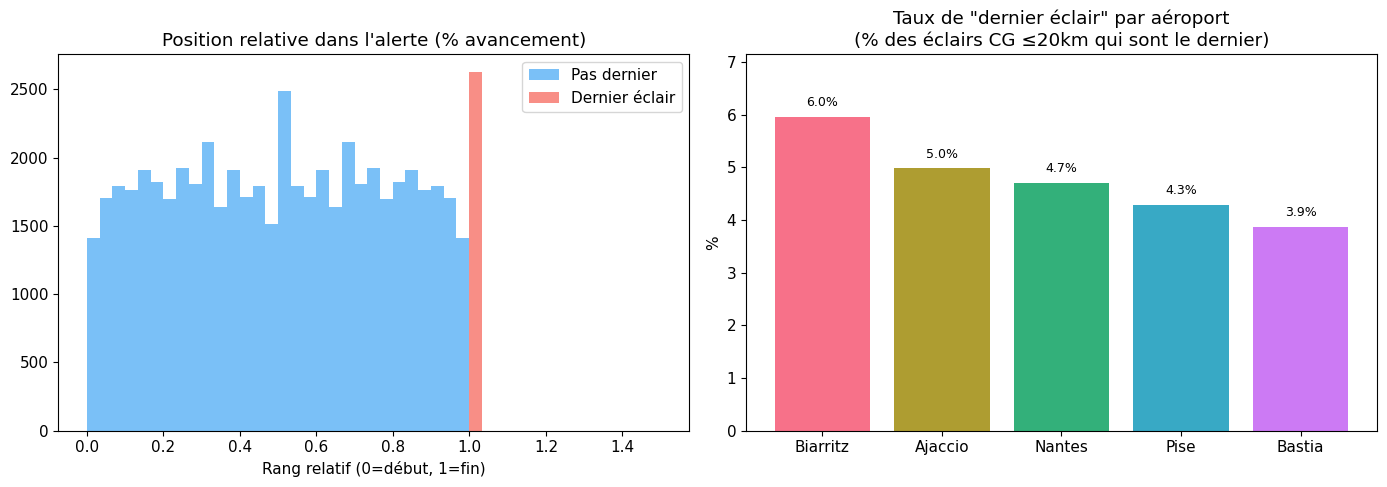

In [13]:
# 6.2 — Rang du dernier éclair dans l'alerte (position relative)
df_target = df_target.sort_values(['airport', 'airport_alert_id', 'date'])
df_target['rank_in_alert'] = df_target.groupby(
    ['airport', 'airport_alert_id']
).cumcount() + 1
df_target['total_in_alert'] = df_target.groupby(
    ['airport', 'airport_alert_id']
)['rank_in_alert'].transform('max')
df_target['rank_pct'] = df_target['rank_in_alert'] / df_target['total_in_alert']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rang relatif
axes[0].hist(
    df_target[df_target['is_last']==0]['rank_pct'], bins=30,
    alpha=0.6, label='Pas dernier', color='#2196F3'
)
axes[0].hist(
    df_target[df_target['is_last']==1]['rank_pct'], bins=30,
    alpha=0.6, label='Dernier éclair', color='#F44336'
)
axes[0].set_title('Position relative dans l\'alerte (% avancement)')
axes[0].set_xlabel('Rang relatif (0=début, 1=fin)')
axes[0].legend()

# Taux de "dernier" par aéroport
taux = df_target.groupby('airport')['is_last'].mean().sort_values(ascending=False)
axes[1].bar(taux.index, taux.values * 100,
            color=sns.color_palette('husl', len(taux)))
axes[1].set_title('Taux de "dernier éclair" par aéroport\n(% des éclairs CG ≤20km qui sont le dernier)')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, taux.max() * 120)
for i, (idx, val) in enumerate(taux.items()):
    axes[1].text(i, val*100 + 0.2, f'{val*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Variables discriminantes : Last vs Not-Last

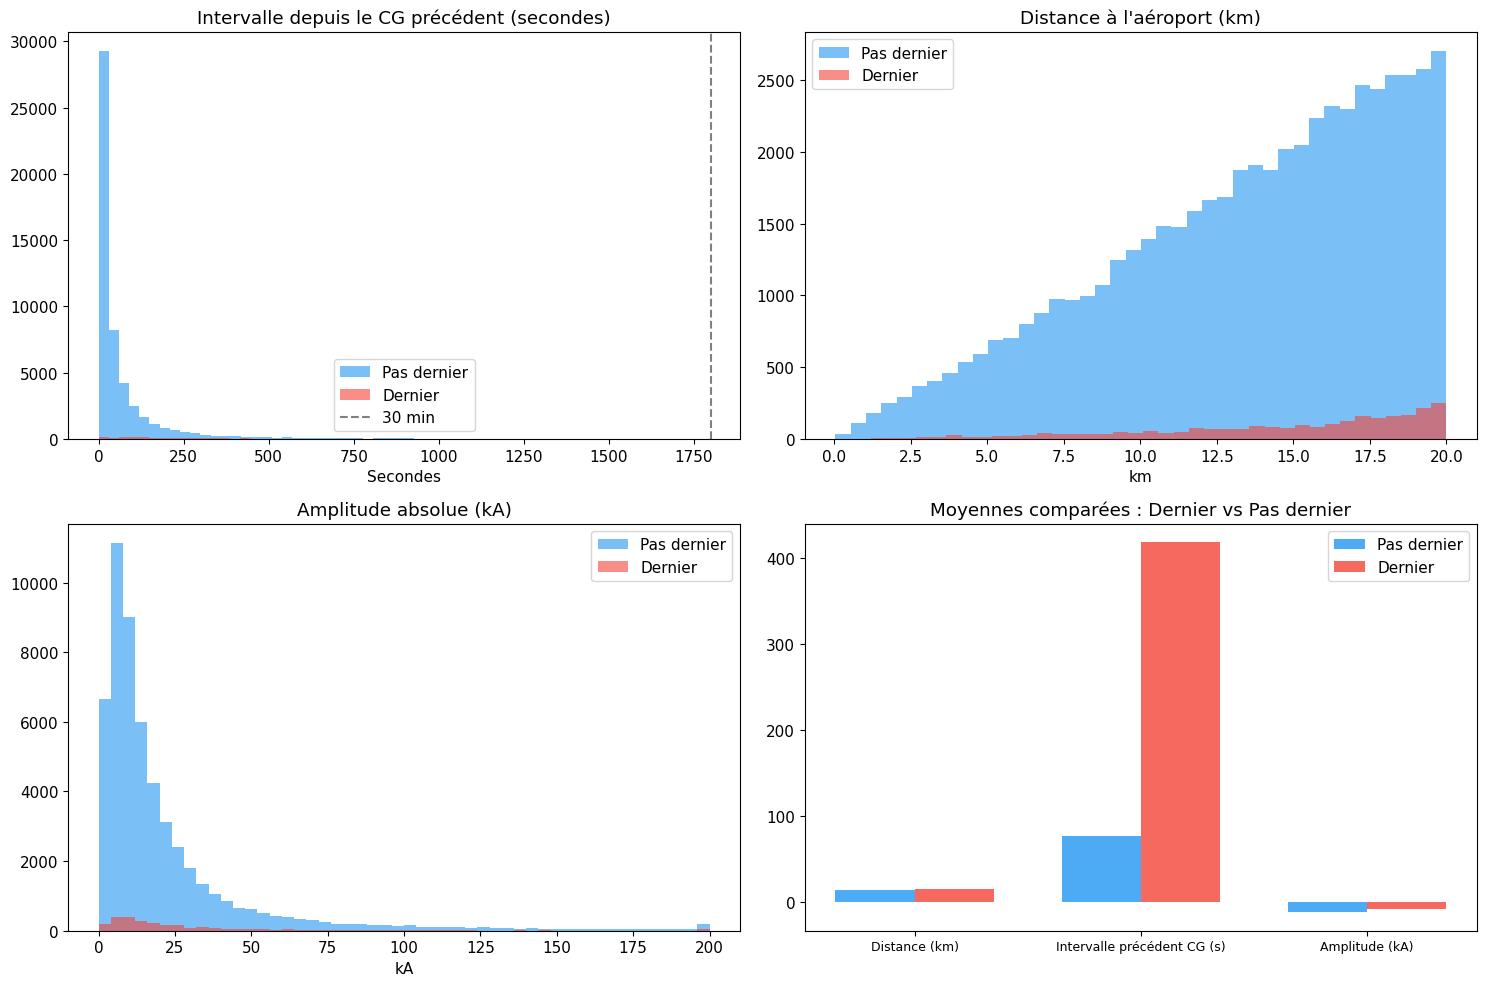

In [14]:
# 7.1 — Temps depuis le précédent éclair CG dans la même alerte
df_target = df_target.sort_values(['airport', 'airport_alert_id', 'date'])
df_target['delta_prev_cg_sec'] = df_target.groupby(
    ['airport', 'airport_alert_id']
)['date'].diff().dt.total_seconds()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 7.2 — Delta depuis précédent CG
for label, color in [(0, '#2196F3'), (1, '#F44336')]:
    data = df_target[df_target['is_last']==label]['delta_prev_cg_sec'].dropna()
    axes[0,0].hist(data.clip(0, 3600), bins=60, alpha=0.6,
                   label='Dernier' if label else 'Pas dernier', color=color)
axes[0,0].set_title('Intervalle depuis le CG précédent (secondes)')
axes[0,0].set_xlabel('Secondes')
axes[0,0].axvline(1800, color='gray', linestyle='--', label='30 min')
axes[0,0].legend()

# 7.3 — Distance
for label, color in [(0, '#2196F3'), (1, '#F44336')]:
    data = df_target[df_target['is_last']==label]['dist']
    axes[0,1].hist(data, bins=40, alpha=0.6,
                   label='Dernier' if label else 'Pas dernier', color=color)
axes[0,1].set_title('Distance à l\'aéroport (km)')
axes[0,1].set_xlabel('km')
axes[0,1].legend()

# 7.4 — Amplitude absolue
for label, color in [(0, '#2196F3'), (1, '#F44336')]:
    data = df_target[df_target['is_last']==label]['amplitude'].abs()
    axes[1,0].hist(data.clip(0, 200), bins=50, alpha=0.6,
                   label='Dernier' if label else 'Pas dernier', color=color)
axes[1,0].set_title('Amplitude absolue (kA)')
axes[1,0].set_xlabel('kA')
axes[1,0].legend()

# 7.5 — Boxplots comparatifs
compare_vars = ['dist', 'delta_prev_cg_sec', 'amplitude']
compare_labels = ['Distance (km)', 'Intervalle précédent CG (s)', 'Amplitude (kA)']
means = df_target.groupby('is_last')[compare_vars].mean().T
means.columns = ['Pas dernier', 'Dernier']
means.index = compare_labels

x = np.arange(len(compare_labels))
width = 0.35
axes[1,1].bar(x - width/2, means['Pas dernier'], width, label='Pas dernier', color='#2196F3', alpha=0.8)
axes[1,1].bar(x + width/2, means['Dernier'], width, label='Dernier', color='#F44336', alpha=0.8)
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(compare_labels, fontsize=9)
axes[1,1].set_title('Moyennes comparées : Dernier vs Pas dernier')
axes[1,1].legend()

plt.tight_layout()
plt.show()

## 8. Analyse Spatiale : Direction des orages (Rose des vents)

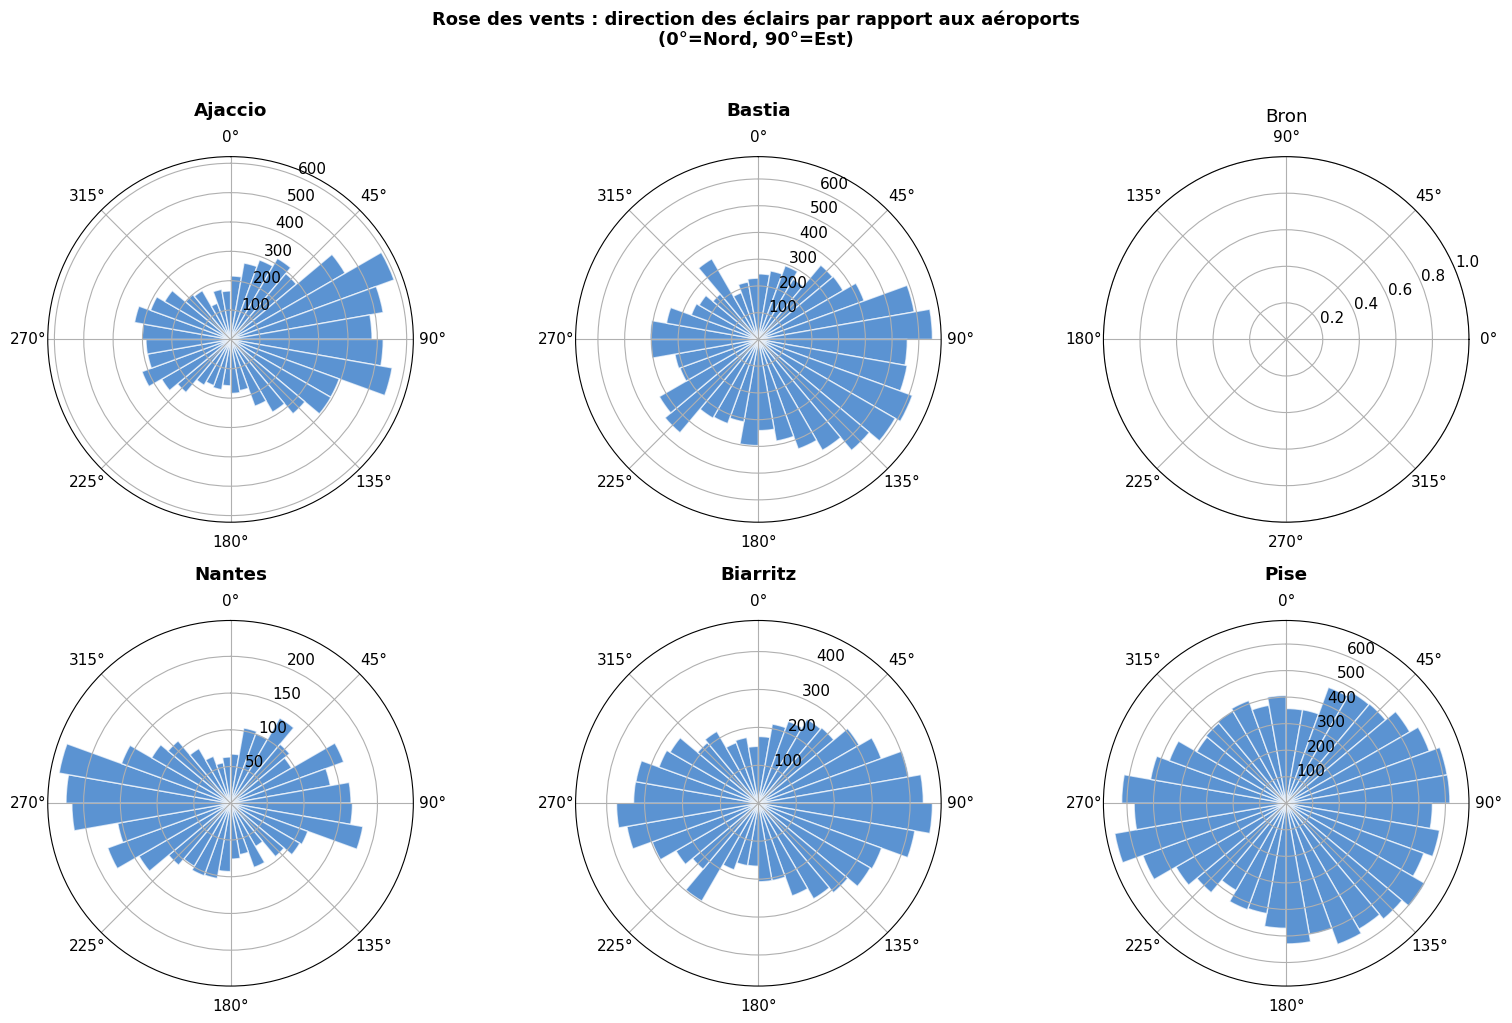

In [15]:
fig = plt.figure(figsize=(16, 10))
n_airports = len(AIRPORTS)
cols = 3
rows = (n_airports + cols - 1) // cols

for idx, airport in enumerate(AIRPORTS):
    ax = fig.add_subplot(rows, cols, idx+1, projection='polar')
    data_ap = df_cg_20[df_cg_20['airport'] == airport]['azimuth'].dropna()

    if len(data_ap) == 0:
        ax.set_title(airport)
        continue

    # Histogramme polaire
    bins = np.linspace(0, 2*np.pi, 37)
    theta = np.deg2rad(data_ap)
    counts_p, _ = np.histogram(theta, bins=bins)
    theta_centers = (bins[:-1] + bins[1:]) / 2

    bars = ax.bar(theta_centers, counts_p, width=2*np.pi/36,
                  alpha=0.7, color='#1565C0', edgecolor='white')
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)  # sens horaire
    ax.set_title(airport, fontweight='bold', pad=10)

plt.suptitle('Rose des vents : direction des éclairs par rapport aux aéroports\n(0°=Nord, 90°=Est)', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Amplitude & Polarité

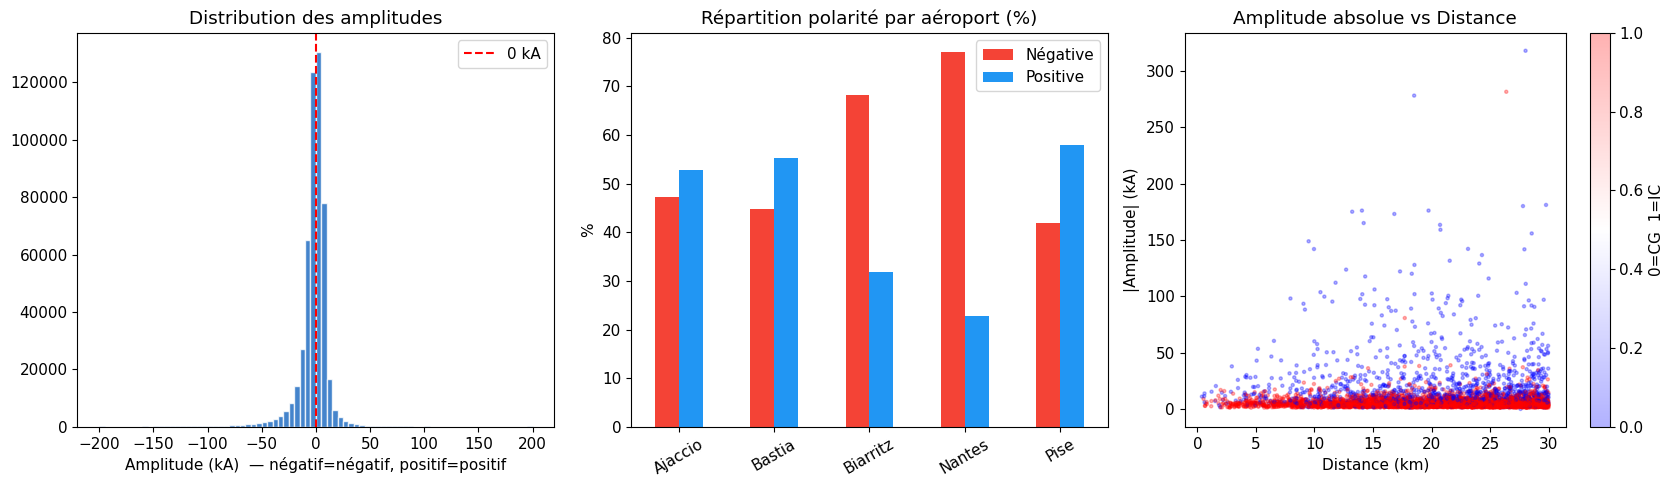

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 9.1 — Distribution amplitude
axes[0].hist(df_clean['amplitude'].clip(-200, 200), bins=80,
             color='#1565C0', alpha=0.8, edgecolor='white')
axes[0].axvline(0, color='red', linewidth=1.5, linestyle='--', label='0 kA')
axes[0].set_title('Distribution des amplitudes')
axes[0].set_xlabel('Amplitude (kA)  — négatif=négatif, positif=positif')
axes[0].legend()

# 9.2 — Polarité par aéroport
df_clean['polarite'] = df_clean['amplitude'].apply(lambda x: 'Positive' if x > 0 else 'Négative')
pol = df_clean.groupby(['airport', 'polarite']).size().unstack(fill_value=0)
pol_pct = pol.div(pol.sum(axis=1), axis=0) * 100
pol_pct.plot(kind='bar', ax=axes[1], color=['#F44336', '#2196F3'])
axes[1].set_title('Répartition polarité par aéroport (%)')
axes[1].set_xlabel('')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

# 9.3 — Amplitude vs distance (scatter)
sample = df_clean.sample(min(5000, len(df_clean)), random_state=42)
scatter = axes[2].scatter(
    sample['dist'], sample['amplitude'].abs(),
    c=sample['icloud'].astype(int), cmap='bwr', alpha=0.3, s=5
)
axes[2].set_title('Amplitude absolue vs Distance')
axes[2].set_xlabel('Distance (km)')
axes[2].set_ylabel('|Amplitude| (kA)')
plt.colorbar(scatter, ax=axes[2], label='0=CG  1=IC')

plt.tight_layout()
plt.show()

## 10. Feature Engineering — Aperçu des features pour la modélisation

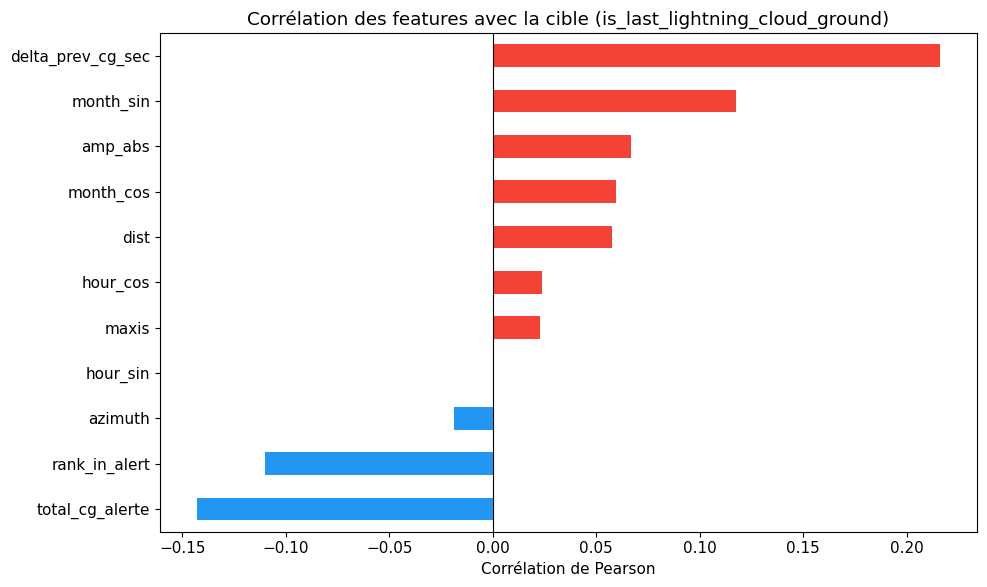

total_cg_alerte     -0.142918
rank_in_alert       -0.109957
azimuth             -0.018809
hour_sin             0.000791
maxis                0.022828
hour_cos             0.023693
dist                 0.057790
month_cos            0.059689
amp_abs              0.066980
month_sin            0.117643
delta_prev_cg_sec    0.216027
Name: is_last, dtype: float64


In [17]:
# Calcul des features sur les éclairs CG ≤ 20 km (avec alert_id)
df_feat = df_target.sort_values(['airport', 'airport_alert_id', 'date']).copy()

grp = df_feat.groupby(['airport', 'airport_alert_id'])

# Intervalle depuis dernier CG (secondes)
df_feat['delta_prev_cg_sec'] = grp['date'].diff().dt.total_seconds().fillna(0)

# Amplitude absolue
df_feat['amp_abs'] = df_feat['amplitude'].abs()

# Nombre d'éclairs CG dans les 5, 10, 15 dernières minutes
df_feat = df_feat.sort_values('date')
for window_min in [5, 10, 15, 30]:
    col = f'n_cg_last_{window_min}min'
    df_feat[col] = (
        df_feat
        .groupby(['airport', 'airport_alert_id'])['date']
        .transform(lambda s: s.expanding().count())  # simplifié
    )  # À remplacer par un vrai rolling sur le temps

# Rang dans l'alerte
df_feat['rank_in_alert'] = grp.cumcount() + 1
df_feat['total_cg_alerte'] = grp['lightning_id'].transform('count')

# Variables cycliques pour l'heure et le mois
df_feat['hour_sin'] = np.sin(2 * np.pi * df_feat['hour'] / 24)
df_feat['hour_cos'] = np.cos(2 * np.pi * df_feat['hour'] / 24)
df_feat['month_sin'] = np.sin(2 * np.pi * df_feat['month'] / 12)
df_feat['month_cos'] = np.cos(2 * np.pi * df_feat['month'] / 12)

# Corrélation avec la cible
feature_cols = ['delta_prev_cg_sec', 'amp_abs', 'dist', 'azimuth',
                'rank_in_alert', 'total_cg_alerte', 'maxis',
                'hour_sin', 'hour_cos', 'month_sin', 'month_cos']

corr_with_target = df_feat[feature_cols + ['is_last']].corr()['is_last'].drop('is_last').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#F44336' if v > 0 else '#2196F3' for v in corr_with_target]
corr_with_target.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Corrélation des features avec la cible (is_last_lightning_cloud_ground)')
ax.set_xlabel('Corrélation de Pearson')
plt.tight_layout()
plt.show()

print(corr_with_target)

## 11. Résumé EDA & Recommandations pour la modélisation

In [46]:
print("""╔══════════════════════════════════════════════════════════════════╗
║              RÉSUMÉ EDA — POINTS CLÉS                           ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. SAISONNALITÉ                                                 ║
║     → Activité orageuse maximale en été (juin–août)              ║
║     → Pics en fin d'après-midi (14h–18h UTC)                     ║
║     → Hétérogénéité géographique forte entre aéroports           ║
║                                                                  ║
║  2. VARIABLE CIBLE                                               ║
║     → Déséquilibre fort : rares « derniers éclairs »             ║
║     → Nécessite SMOTE, class_weight ou seuil adapté              ║
║                                                                  ║
║  3. FEATURES PROMETTEUSES                                        ║
║     → delta_prev_cg : intervalle depuis dernier CG               ║
║     → Tendance de la fréquence (accélération/décélération)       ║
║     → Distance & direction (trajectoire de l'orage)              ║
║     → Amplitude (les orages faiblissent-ils avant de finir ?)    ║
║                                                                  ║
║  4. POINTS D'ATTENTION                                           ║
║     → Pise 2016 : exclure éclairs IC pour analyses comparatives  ║
║     → Évaluer par aéroport (contextes météo différents)          ║
║     → Utiliser une validation croisée temporelle (TimeSeriesSplit)║
║                                                                  ║
║  5. PROCHAINE ÉTAPE                                              ║
║     → Feature engineering complet + baseline LogReg              ║
║     → Modèle XGBoost / LightGBM                                  ║
║     → Évaluation : POD / FTWR / gain de temps moyen              ║
╚══════════════════════════════════════════════════════════════════╝""")

╔══════════════════════════════════════════════════════════════════╗
║              RÉSUMÉ EDA — POINTS CLÉS                           ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. SAISONNALITÉ                                                 ║
║     → Activité orageuse maximale en été (juin–août)              ║
║     → Pics en fin d'après-midi (14h–18h UTC)                     ║
║     → Hétérogénéité géographique forte entre aéroports           ║
║                                                                  ║
║  2. VARIABLE CIBLE                                               ║
║     → Déséquilibre fort : rares « derniers éclairs »             ║
║     → Nécessite SMOTE, class_weight ou seuil adapté              ║
║                                                                  ║
║  3. FEATURES PROMETTEUSES                                        ║
║     → delta_prev_cg : intervalle 